In [43]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

data = pd.read_csv('mnist_dataset.csv')

In [44]:
print (data.shape)

(60000, 785)


In [45]:
''' first number of the shapes attributes shows the no. of rows while the second number shows the coloumns '''

' first number of the shapes attributes shows the no. of rows while the second number shows the coloumns '

In [46]:
data = np.array(data)
m , n = data.shape
np.random.shuffle(data);

data_test = data[0:10000].T
Y_test = data_test[0]
X_test = data_test[1:m]
X_test = X_test/255.

data_train = data[10000:m].T
Y_train = data_train[0]
X_train = data_train[1:m]
X_train = X_train / 255.
_,m_train = X_train.shape


In [47]:
data_train.shape

(785, 50000)

In [48]:
def init_params():
    W1 = np.random.rand(10,784) - 0.5
    b1 = np.random.rand(10,1) - 0.5
    W2 = np.random.rand(10,10) - 0.5
    b2 = np.random.randn(10,1) - 0.5
    return W1,b1,W2,b2

def reLu(Z):
    return np.maximum(0,Z)

def softmax(Z):
    return np.exp(Z)/sum(np.exp(Z))

def fwd_propagation(W1,b1,W2,b2,X):
    Z1 = W1.dot(X) + b1;
    A1 = reLu(Z1)
    Z2 = W2.dot(A1) + b2;
    A2 = softmax(Z2)
    return Z1 , A1 , Z2, A2

def reLu_deriv(Z):
    return Z>0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * reLu_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [49]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = fwd_propagation(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 1000 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [50]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 10000)

Iteration:  0
0.08882
Iteration:  1000
0.87962
Iteration:  2000
0.90048
Iteration:  3000
0.91024
Iteration:  4000
0.91622
Iteration:  5000
0.92156
Iteration:  6000
0.92512
Iteration:  7000
0.92826
Iteration:  8000
0.93108
Iteration:  9000
0.93348


In [51]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = fwd_propagation(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


Prediction:  [7]
Label:  7


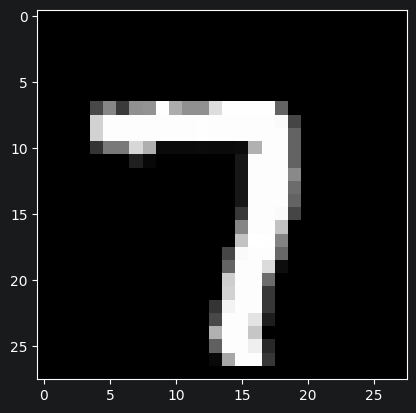

Prediction:  [9]
Label:  4


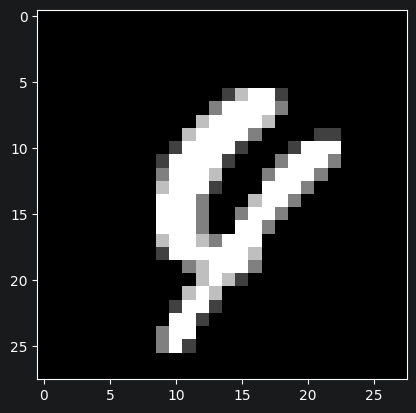

Prediction:  [7]
Label:  1


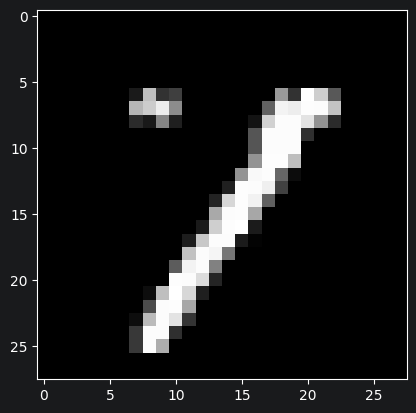

Prediction:  [6]
Label:  6


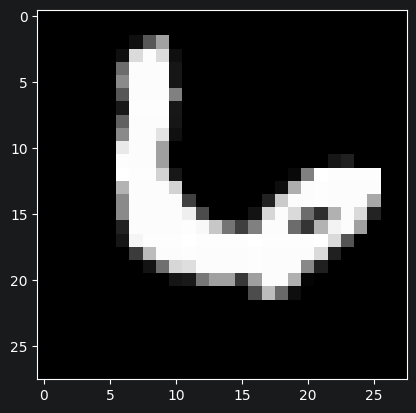

In [52]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

Prediction:  [8]
Label:  8


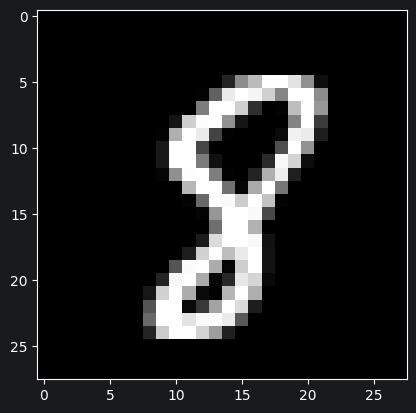

In [53]:
test_prediction(11000, W1, b1, W2, b2)

In [54]:
dev_predictions = make_predictions(X_test, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_test)

np.float64(0.9285)

In [55]:
train_predictions = make_predictions(X_train, W1, b1, W2, b2)
dev_predictions = make_predictions(X_test, W1, b1, W2, b2)

print("Training Accuracy:", get_accuracy(train_predictions, Y_train))
print("Test Accuracy:", get_accuracy(dev_predictions, Y_test))

Training Accuracy: 0.93488
Test Accuracy: 0.9285
